In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    "processed_clause_dataset_clean.csv"
)

In [3]:
df = df.dropna(subset=["clean_text", "clause_type"])

In [4]:
print(df["clean_text"].isna().sum())

0


In [5]:
X = df["clean_text"]
y = df["clause_type"]
print(X.shape)
print(y.shape)

(5693,)
(5693,)


In [6]:
counts = df["clause_type"].value_counts()

valid_classes = counts[counts >= 50].index

df = df[df["clause_type"].isin(valid_classes)]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4554,)
Test: (1139,)


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000,
    min_df=3,
    max_df=0.90,
    ngram_range=(1,2)
                        )
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)

(4554, 5000)


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    C=0.5
)

In [13]:
lr.fit(X_train_tfidf, y_train)
preds = lr.predict(X_test_tfidf)

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_train_tfidf,
    y_train,
    cv=5
)

print(scores.mean())

0.7143141819760921


In [15]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print(
    "Accuracy:",
    accuracy_score(y_test, preds)
)

print(
    classification_report(
        y_test,
        preds
    )
)

Accuracy: 0.6971027216856892
                                    precision    recall  f1-score   support

        Affiliate License-Licensee       0.29      0.50      0.36        12
                    Agreement Date       0.69      0.96      0.81        28
                   Anti-Assignment       0.91      0.91      0.91        75
                      Audit Rights       0.86      0.88      0.87        43
                  Cap On Liability       0.95      0.33      0.49        55
                 Change Of Control       0.67      0.58      0.62        24
 Competitive Restriction Exception       0.29      0.13      0.18        15
               Covenant Not To Sue       0.77      0.85      0.81        20
                     Document Name       0.94      0.98      0.96        85
                    Effective Date       0.68      0.34      0.46        38
                       Exclusivity       0.35      0.25      0.29        36
                   Expiration Date       0.68      0.76   

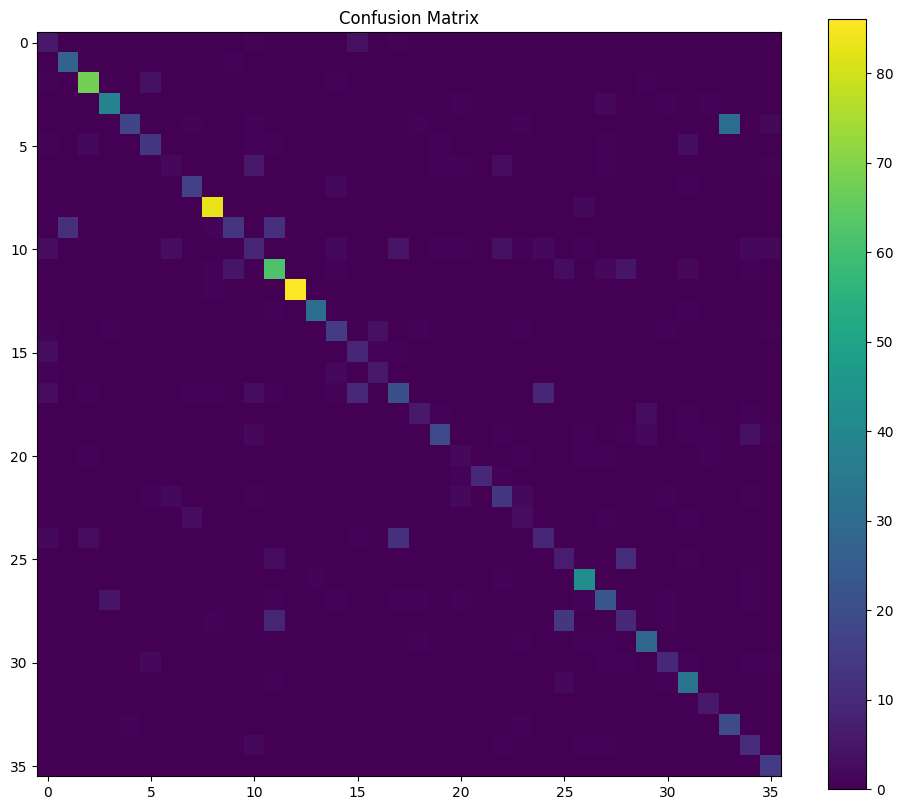

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.show()

In [17]:
import joblib

joblib.dump(
    lr,
    "legal_clause_classifier.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [18]:
train_preds = lr.predict(X_train_tfidf)

from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(y_train, train_preds))
print("Test Accuracy:", accuracy_score(y_test, preds))

Train Accuracy: 0.8320158102766798
Test Accuracy: 0.6971027216856892


In [20]:
print(lr.classes_)

['Affiliate License-Licensee' 'Agreement Date' 'Anti-Assignment'
 'Audit Rights' 'Cap On Liability' 'Change Of Control'
 'Competitive Restriction Exception' 'Covenant Not To Sue' 'Document Name'
 'Effective Date' 'Exclusivity' 'Expiration Date' 'Governing Law'
 'Insurance' 'Ip Ownership Assignment' 'Irrevocable Or Perpetual License'
 'Joint Ip Ownership' 'License Grant' 'Liquidated Damages'
 'Minimum Commitment' 'No-Solicit Of Customers' 'No-Solicit Of Employees'
 'Non-Compete' 'Non-Disparagement' 'Non-Transferable License'
 'Notice Period To Terminate Renewal' 'Parties'
 'Post-Termination Services' 'Renewal Term' 'Revenue/Profit Sharing'
 'Rofr/Rofo/Rofn' 'Termination For Convenience' 'Third Party Beneficiary'
 'Uncapped Liability' 'Volume Restriction' 'Warranty Duration']


In [21]:
clause = "Neither party may assign this Agreement without the prior written consent of the other party."

x = tfidf.transform([clause])

prediction = lr.predict(x)

print("Prediction:", prediction)

Prediction: ['Anti-Assignment']


In [22]:
import pandas as pd

probs = lr.predict_proba(x)[0]

results = pd.DataFrame({
    "Class": lr.classes_,
    "Probability": probs
})

print(
    results.sort_values(
        "Probability",
        ascending=False
    ).head(10)
)

                                 Class  Probability
2                      Anti-Assignment     0.828179
5                    Change Of Control     0.016456
31         Termination For Convenience     0.014668
21             No-Solicit Of Employees     0.009004
25  Notice Period To Terminate Renewal     0.008187
24            Non-Transferable License     0.006559
28                        Renewal Term     0.006393
32             Third Party Beneficiary     0.006018
4                     Cap On Liability     0.005200
8                        Document Name     0.004980


In [23]:
import os

for file in os.listdir():
    if file.endswith(".pkl"):
        print(file)

contracts_metadata.pkl
legal_clause_classifier.pkl
tfidf_vectorizer.pkl
